# Model Group Correlations

Pairwise per-question accuracy correlations across VLM / LM-decoder / Backbone LLM groups.

- **Full 1k** questions used for model–model correlations
- **s2_v2 sample** used for human–model correlations (where human data exists)
- Condition: `inst_blind` throughout
- Reuses `analysis/utils/corr.py` (`interrater_agreement`, `pairwise_metric`, `get_all_cm`)

In [1]:
import re, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.vqa import VQAAnswerMapper, vqa_accuracy
from utils.corr import interrater_agreement, pairwise_metric, get_all_cm

mapper = VQAAnswerMapper()
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Shared constants ──────────────────────────────────────────────────────────
VARIANT_ORDER  = ['C', 'B', 'A']
CT_TO_VARIANT  = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
GROUP_COLORS   = {'VLM': '#E91E63', 'LM-decoder': '#2196F3', 'Backbone LLM': '#FF9800'}

def _clean_answer(ans):
    """Strip <think>...</think> CoT prefix (Qwen3 backbone)."""
    return re.sub(r'<think>.*?</think>\s*', '', ans, flags=re.DOTALL).strip()

print('Ready')

Ready


## 1. Load Model Accuracies (full 1k)

In [11]:
# ── Model registry — same as notebook 09 ────────────────────────────────────
ALL_MODELS = {
    # VLM
    'Qwen3-VL-8B':        (BASE / 'evaluation/logits/pretrained',              'Qwen3-VL-8B-Instruct'),
    'LLaVA-1.5-7B':       (BASE / 'evaluation/logits/pretrained',              'llava-1.5-7b-hf'),
    'LLaVA-Mistral':      (BASE / 'evaluation/logits/pretrained',              'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna':       (BASE / 'evaluation/logits/pretrained',              'llava-v1.6-vicuna-7b-hf'),
    # LM-decoder
    'LLaVA-1.5 (LM)':     (BASE / 'evaluation/logits/lm_decoder/pretrained',   'llava-1.5-7b-hf'),
    'LLaVA-Mistral (LM)': (BASE / 'evaluation/logits/lm_decoder/pretrained',   'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna (LM)':  (BASE / 'evaluation/logits/lm_decoder/pretrained',   'llava-v1.6-vicuna-7b-hf'),
    # Backbone LLM (Vicuna empty, Mistral refuses)
    'Qwen3-8B':           (BASE / 'evaluation/logits/backbone/pretrained',      'Qwen3-8B'),
}

MODEL_TYPE = {
    'Qwen3-VL-8B': 'VLM', 'LLaVA-1.5-7B': 'VLM', 'LLaVA-Mistral': 'VLM', 'LLaVA-Vicuna': 'VLM',
    'LLaVA-1.5 (LM)': 'LM-decoder', 'LLaVA-Mistral (LM)': 'LM-decoder', 'LLaVA-Vicuna (LM)': 'LM-decoder',
    'Qwen3-8B': 'Backbone LLM',
}

# ── Load full-1k accuracies ───────────────────────────────────────────────────
raw = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for label, (results_dir, mdir) in ALL_MODELS.items():
    path = results_dir / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists():
        print(f'  MISSING: {label}')
        continue
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        gt  = mapper.get_answers(qid)
        ga  = ex.get('generated_answers', {})
        for ct, var in CT_TO_VARIANT.items():
            ans = _clean_answer(ga.get(ct, ''))
            if ans and gt:
                raw[label][qid][var].append(vqa_accuracy(ans, gt))

# Build per-model DataFrames indexed by question_id
model_acc = {}   # label → DataFrame(question_id × variant)
for label in ALL_MODELS:
    if label not in raw: continue
    all_qids = sorted(raw[label].keys())
    rows = []
    for qid in all_qids:
        row = {'question_id': qid}
        for var in VARIANT_ORDER:
            vals = raw[label][qid][var]
            row[var] = float(np.mean(vals)) if vals else np.nan
        rows.append(row)
    model_acc[label] = pd.DataFrame(rows).set_index('question_id')

print('Loaded:', list(model_acc.keys()))
for lbl, df in model_acc.items():
    print(f'  [{MODEL_TYPE[lbl]:12}] {lbl}: n={df["C"].notna().sum()}, mean C={df["C"].mean():.3f}')

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Loaded: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']
  [VLM         ] Qwen3-VL-8B: n=999, mean C=0.372
  [VLM         ] LLaVA-1.5-7B: n=1000, mean C=0.340
  [VLM         ] LLaVA-Mistral: n=1000, mean C=0.364
  [VLM         ] LLaVA-Vicuna: n=1000, mean C=0.347
  [LM-decoder  ] LLaVA-1.5 (LM): n=1000, mean C=0.415
  [LM-decoder  ] LLaVA-Mistral (LM): n=1000, mean C=0.420
  [LM-decoder  ] LLaVA-Vicuna (LM): n=1000, mean C=0.396
  [Backbone LLM] Qwen3-8B: n=1000, mean C=0.178


## 2. Pairwise Correlation Matrix (variant C)

In [13]:
# ── Build wide pivot: question_id × model (variant C) ────────────────────────
pivot_C = pd.concat(
    [df['C'].rename(lbl) for lbl, df in model_acc.items()], axis=1
).dropna(how='all')

models    = list(pivot_C.columns)
n_models  = len(models)

# Pairwise Spearman ρ
corr_mat = pd.DataFrame(np.nan, index=models, columns=models, dtype=float)
for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        shared = pivot_C[[m1, m2]].dropna()
        if len(shared) < 5: continue
        corr_mat.loc[m1, m2] = float(pairwise_metric(shared[m1], shared[m2], metric='spearman'))
np.fill_diagonal(corr_mat.values, 1.0)

# ── Plot heatmap ──────────────────────────────────────────────────────────────
type_order = ['VLM', 'LM-decoder', 'Backbone LLM']
sorted_models = sorted(models, key=lambda m: (type_order.index(MODEL_TYPE[m]), m))
corr_sorted = corr_mat.loc[sorted_models, sorted_models]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_sorted, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white',
    square=True, ax=ax, annot_kws={'size': 9},
)

# Draw group boundary lines
boundaries = [sum(1 for m in sorted_models if MODEL_TYPE[m] == t) for t in type_order]
cumulative = np.cumsum(boundaries)
for b in cumulative[:-1]:
    ax.axhline(b, color='black', lw=1.5)
    ax.axvline(b, color='black', lw=1.5)

# Group labels on top
for t, start, end in zip(type_order, [0]+list(cumulative[:-1]), cumulative):
    mid = (start + end) / 2
    ax.text(mid, -0.6, t, ha='center', va='bottom', fontsize=9,
            color=GROUP_COLORS[t], fontweight='bold',
            transform=ax.get_xaxis_transform())

ax.set_title('Pairwise Spearman ρ — inst_blind, variant C (full 1k)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print('\nMean ρ by group pair:')
for t1 in type_order:
    g1 = [m for m in sorted_models if MODEL_TYPE[m] == t1]
    for t2 in type_order:
        if t2 < t1: continue
        g2 = [m for m in sorted_models if MODEL_TYPE[m] == t2]
        vals = [corr_mat.loc[m1, m2] for m1 in g1 for m2 in g2
                if m1 != m2 and not np.isnan(corr_mat.loc[m1, m2])]
        if vals:
            print(f'  {t1:12} × {t2:12}  mean ρ = {np.mean(vals):.3f}  (n={len(vals)} pairs)')

ValueError: setting an array element with a sequence.

## 3. Correlation Across Variants (C / B / A)

variant      within-group ρ     between-group ρ
--------------------------------------------------
C                    0.718               0.448
B                    0.717               0.433
A                    0.732               0.379


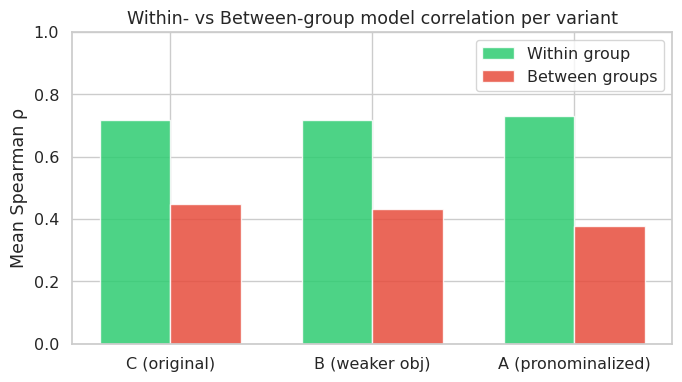

In [14]:
# ── Pairwise ρ for each variant, summarised as within- vs between-group ───────
results = []
for var in VARIANT_ORDER:
    pivot_v = pd.concat(
        [df[var].rename(lbl) for lbl, df in model_acc.items()], axis=1
    ).dropna(how='all')
    for m1 in models:
        for m2 in models:
            if m1 >= m2: continue
            shared = pivot_v[[m1, m2]].dropna()
            if len(shared) < 5: continue
            rho = pairwise_metric(shared[m1], shared[m2], metric='spearman')
            same_group = MODEL_TYPE[m1] == MODEL_TYPE[m2]
            results.append({
                'variant': var, 'm1': m1, 'm2': m2,
                'group1': MODEL_TYPE[m1], 'group2': MODEL_TYPE[m2],
                'same_group': same_group, 'rho': rho,
            })

rdf = pd.DataFrame(results)

# Summary table
print(f'{"variant":6}  {"within-group ρ":>18}  {"between-group ρ":>18}')
print('-' * 50)
for var in VARIANT_ORDER:
    sub = rdf[rdf.variant == var]
    w = sub[sub.same_group]['rho'].mean()
    b = sub[~sub.same_group]['rho'].mean()
    print(f'{var:6}  {w:>18.3f}  {b:>18.3f}')

# ── Bar chart: within vs between per variant ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(VARIANT_ORDER))
w = 0.35
within  = [rdf[(rdf.variant==v) & rdf.same_group]['rho'].mean()  for v in VARIANT_ORDER]
between = [rdf[(rdf.variant==v) & ~rdf.same_group]['rho'].mean() for v in VARIANT_ORDER]
ax.bar(x - w/2, within,  w, label='Within group',   color='#2ecc71', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, between, w, label='Between groups', color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['C (original)', 'B (weaker obj)', 'A (pronominalized)'])
ax.set_ylabel('Mean Spearman ρ')
ax.set_title('Within- vs Between-group model correlation per variant')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Per-group Agreement (interrater_agreement)

In [15]:
# ── Use interrater_agreement from corr.py for within-group ρ + CI ─────────────
for var in VARIANT_ORDER:
    pivot_v = pd.concat(
        [df[var].rename(lbl) for lbl, df in model_acc.items()], axis=1
    ).dropna(how='all')

    print(f'\n=== Variant {var} ===')
    for gname in ['VLM', 'LM-decoder', 'Backbone LLM']:
        grp = [m for m in models if MODEL_TYPE[m] == gname and m in pivot_v.columns]
        if len(grp) < 2: continue
        result = interrater_agreement(pivot_v, grp1=grp, grp2=grp,
                                      metric='spearman', title=gname)
        print(f'  {gname:14}  ρ = {result["mean_r"]:.3f}  '
              f'[{result["ci_2p5"]:.3f}, {result["ci_97p5"]:.3f}]  '
              f'n={len(grp)} models')


=== Variant C ===
  VLM             ρ = 0.722  [0.552, 0.892]  n=4 models
  LM-decoder      ρ = 0.712  [0.634, 0.789]  n=3 models

=== Variant B ===
  VLM             ρ = 0.718  [0.535, 0.901]  n=4 models
  LM-decoder      ρ = 0.714  [0.637, 0.791]  n=3 models

=== Variant A ===
  VLM             ρ = 0.766  [0.566, 0.965]  n=4 models
  LM-decoder      ρ = 0.663  [0.480, 0.845]  n=3 models


## 5. Cross-group Correlation Heatmap (all variants)

NameError: name 'sorted_models' is not defined

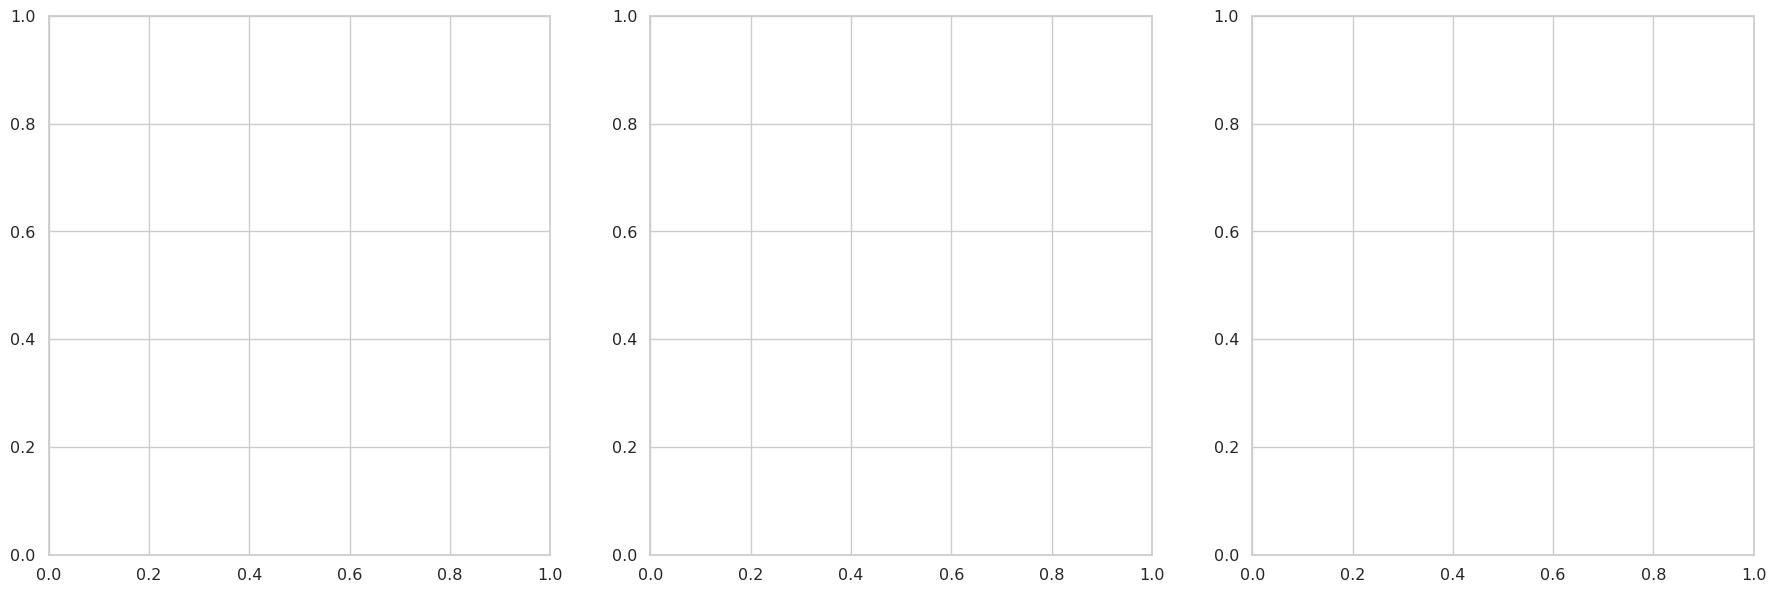

In [17]:
# ── 3-panel heatmap: one per variant ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, var in zip(axes, VARIANT_ORDER):
    pivot_v = pd.concat(
        [df[var].rename(lbl) for lbl, df in model_acc.items()], axis=1
    ).dropna(how='all')

    cm = pd.DataFrame(np.nan, index=sorted_models, columns=sorted_models, dtype=float)
    for m1 in sorted_models:
        for m2 in sorted_models:
            if m1 not in pivot_v or m2 not in pivot_v: continue
            shared = pivot_v[[m1, m2]].dropna()
            if len(shared) < 5: continue
            cm.loc[m1, m2] = float(pairwise_metric(shared[m1], shared[m2], metric='spearman'))
    np.fill_diagonal(cm.values, 1.0)

    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-0.2, vmax=1, center=0.5,
        linewidths=0.4, linecolor='white',
        square=True, ax=ax, annot_kws={'size': 7.5},
        cbar=ax is axes[-1],
    )
    for b in cumulative[:-1]:
        ax.axhline(b, color='black', lw=1.2)
        ax.axvline(b, color='black', lw=1.2)
    ax.set_title(f'Variant {var}', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7.5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7.5)

plt.suptitle('Pairwise Spearman ρ — inst_blind (full 1k)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Entity-level Correlation (ent × model group)

In [7]:
# ── Load s2 metadata for ent/op labels ───────────────────────────────────────
s2_meta = pd.read_csv(BASE / 'experiment/s2_v2/s2.csv')[['question_id','ent','op','ent_grp','op_grp']]
ent_order = sorted(s2_meta['ent'].unique())

# ── For each ent, compute group-mean C accuracy and pairwise VLM–Backbone ρ ───
rows = []
for ent in ent_order:
    qids = set(s2_meta[s2_meta.ent == ent]['question_id'])
    for gname in ['VLM', 'LM-decoder', 'Backbone LLM']:
        grp_models = [m for m in models if MODEL_TYPE[m] == gname]
        accs = []
        for m in grp_models:
            sub = model_acc[m]['C']
            sub_ent = sub[sub.index.isin(qids)].dropna()
            if len(sub_ent) >= 3:
                accs.append(sub_ent.mean())
        if accs:
            rows.append({'ent': ent, 'group': gname, 'mean_C': np.mean(accs), 'n_models': len(accs)})

ent_grp_df = pd.DataFrame(rows)

# ── Grouped bar: entity × model group ────────────────────────────────────────
x        = np.arange(len(ent_order))
grp_list = ['VLM', 'LM-decoder', 'Backbone LLM']
n_grps   = len(grp_list)
w        = 0.7 / n_grps
offsets  = np.linspace(-(n_grps-1)/2, (n_grps-1)/2, n_grps) * w

fig, ax = plt.subplots(figsize=(13, 4))
for gname, offset in zip(grp_list, offsets):
    sub = ent_grp_df[ent_grp_df.group == gname].set_index('ent')
    vals = [sub.loc[e, 'mean_C'] if e in sub.index else np.nan for e in ent_order]
    ax.bar(x + offset, vals, w, color=GROUP_COLORS[gname],
           alpha=0.85, edgecolor='white', label=gname)

ax.set_xticks(x)
ax.set_xticklabels(ent_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean C accuracy')
ax.set_title('Accuracy by entity type × model group — inst_blind (s2 sample)')
ax.axhline(0.5, color='gray', ls='--', lw=0.7)
ax.legend(); ax.set_ylim(0, 0.9)
plt.tight_layout()
plt.show()

NameError: name 'models' is not defined

## 7. Op-level Correlation (op × model group)

In [8]:
op_order = sorted(s2_meta['op'].unique())

rows_op = []
for op in op_order:
    qids = set(s2_meta[s2_meta.op == op]['question_id'])
    for gname in ['VLM', 'LM-decoder', 'Backbone LLM']:
        grp_models = [m for m in models if MODEL_TYPE[m] == gname]
        accs = []
        for m in grp_models:
            sub = model_acc[m]['C']
            sub_op = sub[sub.index.isin(qids)].dropna()
            if len(sub_op) >= 3:
                accs.append(sub_op.mean())
        if accs:
            rows_op.append({'op': op, 'group': gname, 'mean_C': np.mean(accs), 'n': len(accs)})

op_grp_df = pd.DataFrame(rows_op)

x2       = np.arange(len(op_order))
fig, ax  = plt.subplots(figsize=(13, 4))
for gname, offset in zip(grp_list, offsets):
    sub  = op_grp_df[op_grp_df.group == gname].set_index('op')
    vals = [sub.loc[o, 'mean_C'] if o in sub.index else np.nan for o in op_order]
    ax.bar(x2 + offset, vals, w, color=GROUP_COLORS[gname],
           alpha=0.85, edgecolor='white', label=gname)

ax.set_xticks(x2)
ax.set_xticklabels(op_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean C accuracy')
ax.set_title('Accuracy by operation type × model group — inst_blind (s2 sample)')
ax.axhline(0.5, color='gray', ls='--', lw=0.7)
ax.legend(); ax.set_ylim(0, 0.9)
plt.tight_layout()
plt.show()

NameError: name 'models' is not defined